# Customer Analytics - Exploratory Data Analysis

## Objective

To analyze customer behavior based on gender distribution and footfall patterns using collected and simulated data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("simulated_customer_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,timestamp,person_id,gender,hour,day_type
0,2026-04-24 10:07:09,0,Female,10,Weekday
1,2026-04-24 10:09:16,1,Male,10,Weekday
2,2026-04-24 10:17:54,2,Male,10,Weekday
3,2026-04-24 10:21:41,3,Male,10,Weekday
4,2026-04-24 10:22:01,4,Male,10,Weekday


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  382 non-null    datetime64[ns]
 1   person_id  382 non-null    int64         
 2   gender     382 non-null    object        
 3   hour       382 non-null    int64         
 4   day_type   382 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 15.0+ KB


In [5]:
df.describe()

,timestamp,person_id,hour
count,382,382.000000,382.000000
mean,2026-04-24 17:18:18.109947904,190.500000,16.785340
min,2026-04-24 10:07:09,0.000000,10.000000
25%,2026-04-24 14:03:12.750000128,95.250000,14.000000
50%,2026-04-24 18:29:16.500000,190.500000,18.000000
75%,2026-04-24 20:19:10.750000128,285.750000,20.000000
max,2026-04-24 21:59:42,381.000000,21.000000
std,NaN,110.418145,3.513154


In [6]:
df.isnull().sum()

timestamp    0
person_id    0
gender       0
hour         0
day_type     0
dtype: int64

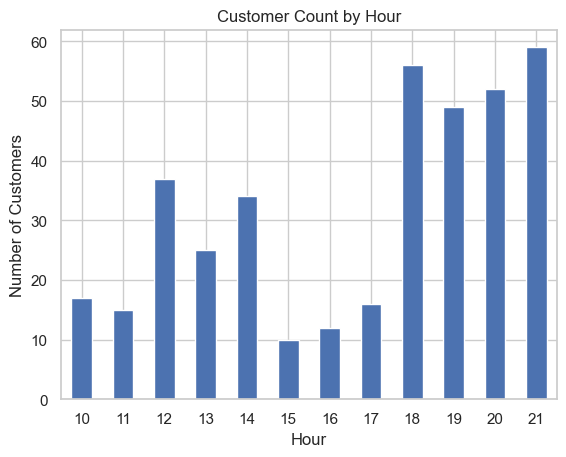

In [7]:
#Customer Count by Hour
df.groupby("hour").size().plot(kind="bar")
plt.title("Customer Count by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

Customer traffic increases significantly during evening hours (6 PM – 9 PM), indicating peak activity.

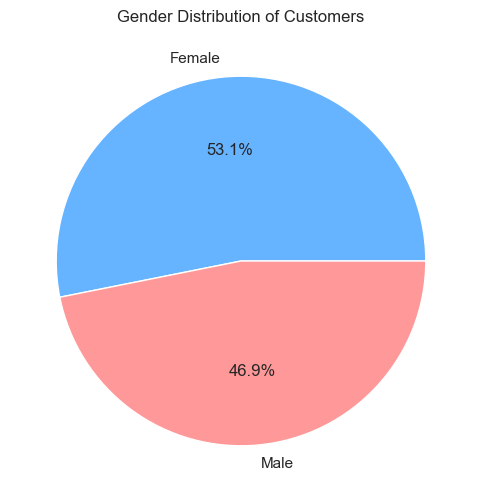

In [8]:
# Gender Distribution Chart
plt.figure(figsize=(6,6))

df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#66b3ff","#ff9999"]
)

plt.title("Gender Distribution of Customers")
plt.ylabel("")
plt.show()

The dataset shows a balanced gender distribution among customers.

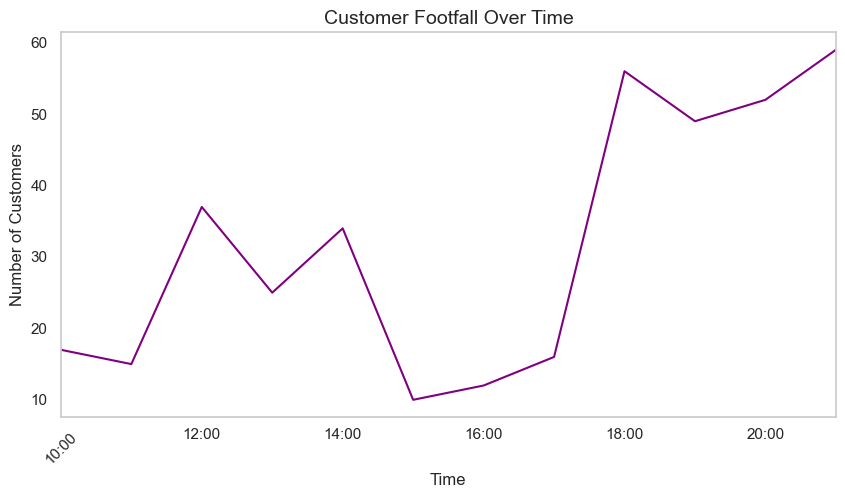

In [9]:
# Footfall Over Time
plt.figure(figsize=(10,5))

df.set_index("timestamp").resample("1h").size().plot(color="purple")

plt.title("Customer Footfall Over Time", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Customer traffic increases towards evening hours.

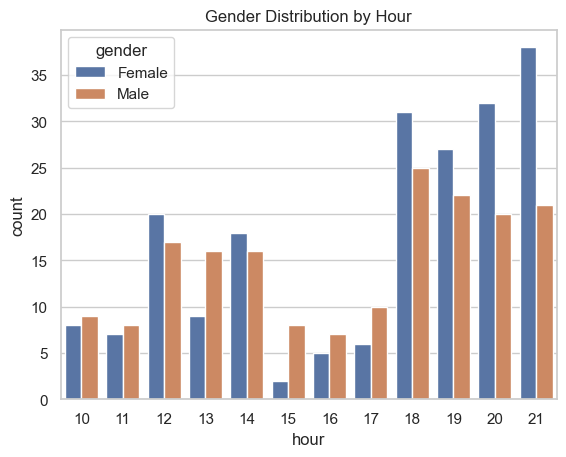

In [11]:
#Gender vs Time
sns.countplot(data=df, x="hour", hue="gender")
plt.title("Gender Distribution by Hour")
plt.show()

Female customers dominate during peak hours.

In [16]:
#Peak Hour Detection
peak_hours = df.groupby("hour").size().sort_values(ascending=False).head()
print("Top 5 Peak Hours:")
for hour, count in peak_hours.items():
    print(f"{hour}:00 → {count} customers")


Top 5 Peak Hours:
21:00 → 59 customers
18:00 → 56 customers
20:00 → 52 customers
19:00 → 49 customers
12:00 → 37 customers


In [14]:
#Total Customers
print("Total Unique Customers:", df["person_id"].nunique())

Total Unique Customers: 382


Final Insights:

1. Customer traffic is highest during evening hours (6 PM – 9 PM), indicating peak shopping activity.

2. The highest footfall is observed at 9 PM, followed by 6 PM and 8 PM.

3. Gender distribution is relatively balanced, with slight variation across different time periods.

4. Female customer presence increases during peak hours, suggesting higher engagement in evening shopping.

5. Morning hours show comparatively lower customer traffic.